# Notebook 01: Exploratory Data Analysis & Preprocessing Pipeline

**Project 3.1: Heart Disease Diagnosis Using Machine Learning**  
AI VIET NAM – AI Course 2026

---
### Objectives:
1. Load and inspect the Cleveland Heart Disease dataset (303 records, 14 attributes).
2. Handle missing values marked by `'?'` and binarize the multi-class target variable.
3. Perform exploratory data analysis (EDA): correlation matrix, distributions, age regressions.
4. Construct a strict Scikit-Learn `ColumnTransformer` to prevent **Data Leakage**.
5. Engineer interaction features (`chol_per_age`, `bps_per_age`, `hr_ratio`, `age_bin`).
6. Perform Feature Selection with **Mutual Information** and **Decision Tree MDI**.
7. Export 4 dataset variants: `Original`, `FE`, `Original + DT`, and `FE + DT`.

In [1]:
# Step 1: Imports and Environment Setup
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is on sys.path
sys.path.append(str(Path.cwd().parent))
from src.config import ALL_COLUMNS, NUMERIC_COLUMNS, CATEGORICAL_COLUMNS, SEED, TARGET, FEATURE_COLUMNS

# Fix seeds for exact reproducibility
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
print(f"[✓] Environment configured with SEED={SEED}")

[✓] Environment configured with SEED=42


## 1. Data Ingestion & Target Binarization

**TODO for you:**
- Load `cleveland.csv` (or fetch via `data/download_data.py`).
- Coerce strings with `?` in numeric columns into `np.nan`.
- Transform `target`: $y > 0 \implies 1$ (disease), $y = 0 \implies 0$ (healthy).

In [2]:
# TODO: Load raw data, assign column names, coerce numeric, binarize target
# Hint: from src.data.loader import load_raw_data
from src.data.loader import load_raw_data
raw_df = load_raw_data("../data/cleveland.csv")
#display(raw_df.head())
print(raw_df.info())


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


## 2. Exploratory Data Analysis (EDA)

**TODO for you:**
- Plot the Pearson Correlation Matrix across numeric features.
- Generate pairplots colored by diagnosis label.
- Fit linear regression lines (`np.polyfit(age, metric, 1)`) for `chol`, `trestbps`, and `thalach` vs. `age`.

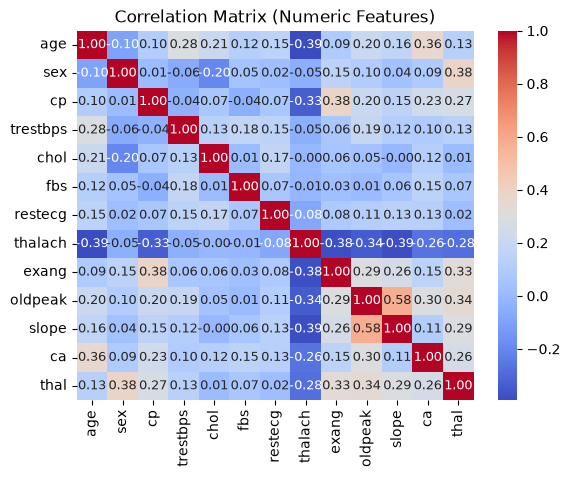

In [3]:
# TODO: Create correlation heatmap & regression plots
# Hint: from src.evaluation.visualization import plot_correlation_matrix, plot_scatter_with_regress
from src.evaluation.visualization import plot_correlation_matrix, plot_scatter_with_regression
plot_correlation_matrix(raw_df, columns=FEATURE_COLUMNS)

## 3. Stratified Dataset Splitting

**TODO for you:**
- Perform a 2-stage train/val/test split (80% / 10% / 10%).
- **Critical:** Use `stratify=y` to preserve label proportions across all splits!

In [6]:
%load_ext autoreload
%autoreload 2

# TODO: Split dataset into X_train, X_val, X_test, y_train, y_val, y_test
# Hint: from src.data.loader import split_dataset
from src.data.loader import split_dataset, save_splits
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(raw_df)
raw_splits = {
    "raw_train": pd.concat([X_train, y_train], axis=1),
    "raw_val": pd.concat([X_val, y_val], axis=1),
    "raw_test": pd.concat([X_test, y_test], axis=1),
}

save_splits(raw_splits,output_dir='/home/hoangLD/Desktop/AIVIETNAM/Module-03/Project 3.1/data/proccessed')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[✓] Saved split raw_train (242 rows, 14 cols) -> /home/hoangLD/Desktop/AIVIETNAM/Module-03/Project 3.1/data/proccessed/raw_train.csv
[✓] Saved split raw_val (30 rows, 14 cols) -> /home/hoangLD/Desktop/AIVIETNAM/Module-03/Project 3.1/data/proccessed/raw_val.csv
[✓] Saved split raw_test (31 rows, 14 cols) -> /home/hoangLD/Desktop/AIVIETNAM/Module-03/Project 3.1/data/proccessed/raw_test.csv


## 4. Preprocessing & Feature Engineering Pipelines

**TODO for you:**
- Implement `SimpleImputer` (median for numeric, mode for categorical).
- Apply `StandardScaler` / `MinMaxScaler` / `OneHotEncoder`.
- Add interaction features: `chol_per_age`, `bps_per_age`, `hr_ratio`, `age_bin`.
- Use `mutual_info_classif` and `DecisionTreeClassifier` to select Top-K features.
- Save exported splits to `../data/splits/`.

In [ ]:
# TODO: Fit transformers on Train ONLY, transform Val and Test
# Hint: from src.features.engineering import AddNewFeaturesTransformer
# Hint: from src.features.selection import select_top_k_mutual_info, select_top_k_decision_tree
